In [1]:
import matplotlib.pyplot as pl
import numpy as np
import pandas as pd
import xarray as xr
import math
import pickle

from fair import FAIR
from fair.interface import fill, initialise
from fair.io import read_properties
from pygments.lexers.textfmts import TodotxtLexer

In [2]:


with open("/glade/work/stevenxu/FAIR_models/origional_model_extension.pkl", "rb") as f_in:
    f1 = pickle.load(f_in)

with open("/glade/work/stevenxu/FAIR_models/top10_model_extension.pkl", "rb") as f_in:
    f2 = pickle.load(f_in)

with open("/glade/work/stevenxu/FAIR_models/top20_model_extension.pkl", "rb") as f_in:
    f3 = pickle.load(f_in)

In [3]:
fancy_titles = {
    "high-extension": "High Extension",
    "high-overshoot": "High Overshoot",
    "medium-overshoot": "Medium Overshoot",
    "medium-extension": "Medium Extension",
    "low": "Low",
    "verylow": "Very Low",
    "verylow-overshoot": "Very Low Overshoot",
}

colors = {
    "high-extension": "#8B0000",        # Dark red
    "high-overshoot": "#DC143C",        # Crimson
    "medium-overshoot": "#FF4500",      # Orange red
    "medium-extension": "#FFA500",      # Orange
    "low": "#00BFFF",                   # Deep sky blue
    "verylow": "#4169E1",               # Royal blue
    "verylow-overshoot": "#0000FF",     # Dark blue
}

weights_51yr = np.ones(52)
weights_51yr[0] = 0.5
weights_51yr[-1] = 0.5

# TOP10

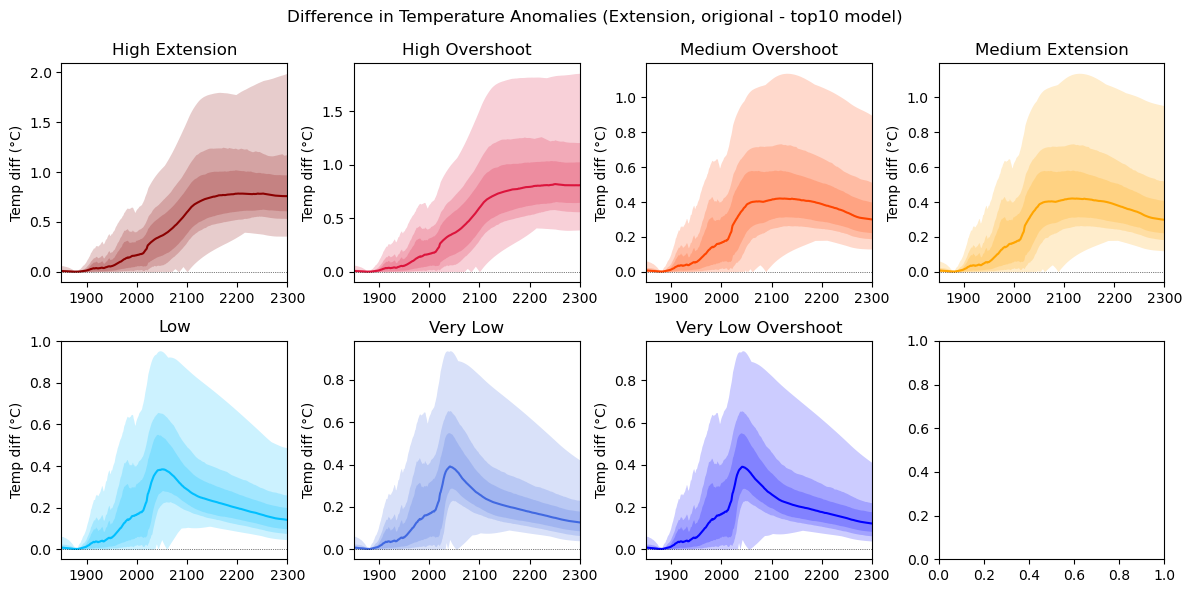

In [4]:
fig, ax = pl.subplots(2, 4, figsize=(12, 6))

for i, scenario in enumerate(f1.scenarios):
    # Calculate the temperature anomaly for f1
    temp1 = f1.temperature.loc[dict(scenario=scenario, layer=0)] - np.average(
        f1.temperature.loc[dict(scenario=scenario, timebounds=np.arange(1850, 1902), layer=0)],
        weights=weights_51yr,
        axis=0
    )
    # Same for f2
    temp2 = f2.temperature.loc[dict(scenario=scenario, layer=0)] - np.average(
        f2.temperature.loc[dict(scenario=scenario, timebounds=np.arange(1850, 1902), layer=0)],
        weights=weights_51yr,
        axis=0
    )

    # Difference between the two models
    diff = abs(temp1 - temp2)

    # Shaded percentile ranges for the difference
    for pp in ((0, 100), (5, 95), (16, 84)):
        ax[i // 4, i % 4].fill_between(
            f1.timebounds,
            np.percentile(diff, pp[0], axis=1),
            np.percentile(diff, pp[1], axis=1),
            color=colors[f1.scenarios[i]],
            alpha=0.2,
            lw=0
        )

    # Median difference line
    ax[i // 4, i % 4].plot(
        f1.timebounds,
        np.median(diff, axis=1),
        color=colors[f1.scenarios[i]],
    )

    ax[i // 4, i % 4].set_xlim(1850, 2300)
    ax[i // 4, i % 4].axhline(0, color="k", ls=":", lw=0.5)
    ax[i // 4, i % 4].set_title(fancy_titles[f1.scenarios[i]])
    ax[i // 4, i % 4].set_ylabel("Temp diff (°C)")

pl.suptitle("Difference in Temperature Anomalies (Extension, origional - top10 model)")
fig.tight_layout()


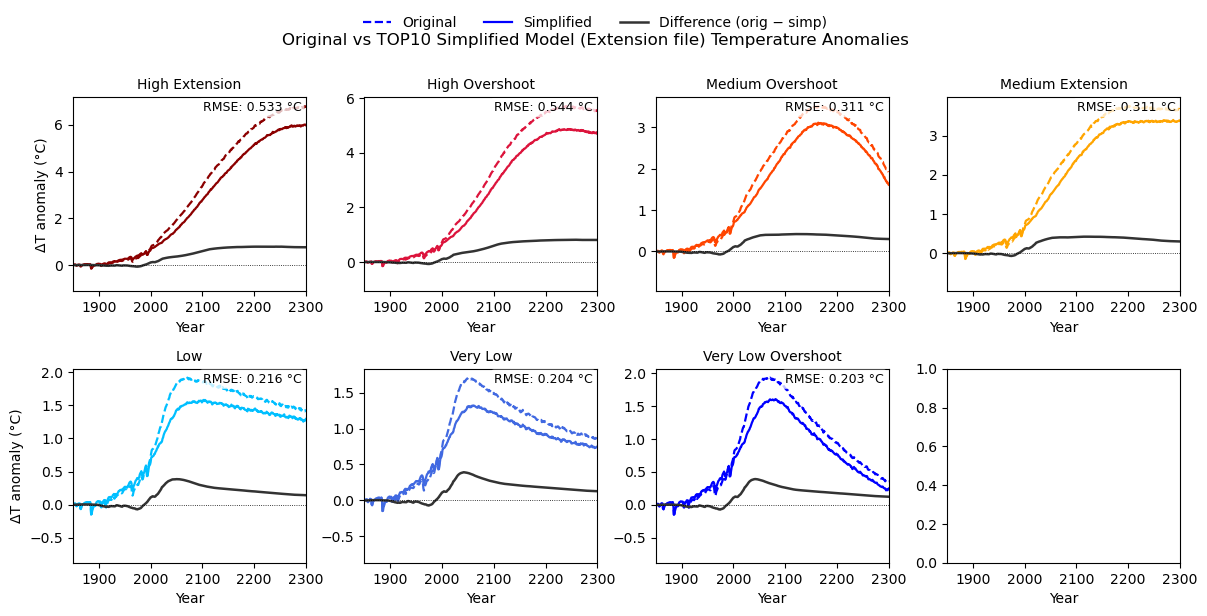

In [5]:
fig, ax = pl.subplots(2, 4, figsize=(12, 6), sharex=True)

# Choose styles for the three lines
STYLE_ORIG = dict(ls='--',  lw=1.6)
STYLE_SIMP = dict(ls='-', lw=1.6)
STYLE_DIFF = dict(ls='-',  lw=1.8)

for i, scenario in enumerate(f1.scenarios):
    a = ax[i // 4, i % 4]

    # --- Temperature anomalies (align baselines) ---
    temp1 = f1.temperature.loc[dict(scenario=scenario, layer=0)] - np.average(
        f1.temperature.loc[dict(scenario=scenario, timebounds=np.arange(1850, 1902), layer=0)],
        weights=weights_51yr, axis=0
    )
    temp2 = f2.temperature.loc[dict(scenario=scenario, layer=0)] - np.average(
        f2.temperature.loc[dict(scenario=scenario, timebounds=np.arange(1850, 1902), layer=0)],
        weights=weights_51yr, axis=0
    )

    # Signed difference
    delta = temp1 - temp2  # (time, ensemble?) → we’ll plot the median over members below if 2D

    # If arrays are (time, member), take the median trajectory for plotting
    def midline(x):
        x = np.asarray(x)
        return np.median(x, axis=1) if x.ndim == 2 else np.asarray(x)

    t = np.asarray(f1.timebounds)
    y1 = midline(temp1)
    y2 = midline(temp2)
    yd = midline(delta)

    # Colors per scenario for the two model lines; diff in neutral color
    scen_color = colors.get(f1.scenarios[i], 'C0')

    p1, = a.plot(t, y1, color=scen_color, **STYLE_ORIG, label='Original')
    p2, = a.plot(t, y2, color=scen_color, **STYLE_SIMP, label='Simplified')
    p3, = a.plot(t, yd, color='0.2',      **STYLE_DIFF, label='Difference (orig − simp)')

    a.axhline(0, color="k", ls=":", lw=0.6)
    a.set_xlim(1850, 2300)
    a.set_title(fancy_titles.get(f1.scenarios[i], f1.scenarios[i]), fontsize=10)
    if i % 4 == 0:
        a.set_ylabel("ΔT anomaly (°C)")

    # --- RMSE (over all times & ensemble members) ---
    rmse = np.sqrt(np.nanmean(np.asarray(delta)**2))
    a.text(
        0.98, 0.98, f"RMSE: {rmse:.3f} °C",
        transform=a.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.75)
    )

# Shared legend (once) — uses the artists from the last loop
fig.legend(
    handles=[p1, p2, p3], loc='upper center', ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.03)
)

for a in ax[0, :]:
    a.tick_params(axis='x', which='both', labelbottom=True)
    a.set_xlabel("Year")

for a in ax[1, :]:
    a.tick_params(axis='x', which='both', labelbottom=True)
    a.set_xlabel("Year")

pl.suptitle("Original vs TOP10 Simplified Model (Extension file) Temperature Anomalies")
fig.tight_layout(rect=[0, 0, 1, 0.98])


# TOP 20

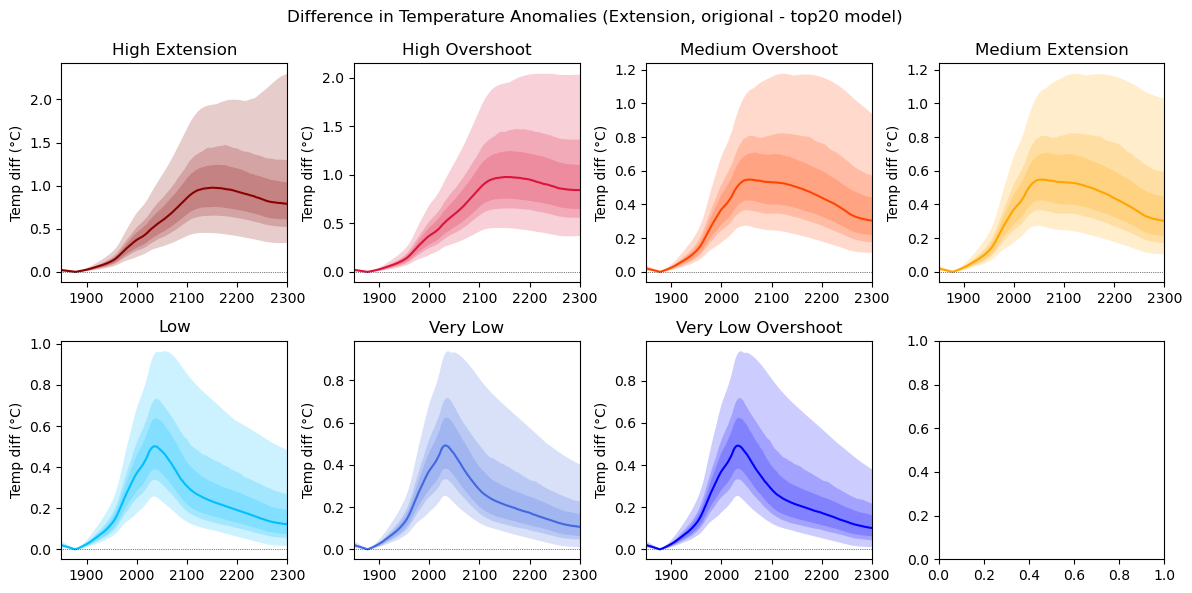

In [6]:
fig, ax = pl.subplots(2, 4, figsize=(12, 6))

for i, scenario in enumerate(f1.scenarios):
    # Calculate the temperature anomaly for f1
    temp1 = f1.temperature.loc[dict(scenario=scenario, layer=0)] - np.average(
        f1.temperature.loc[dict(scenario=scenario, timebounds=np.arange(1850, 1902), layer=0)],
        weights=weights_51yr,
        axis=0
    )
    # Same for f3
    temp2 = f3.temperature.loc[dict(scenario=scenario, layer=0)] - np.average(
        f3.temperature.loc[dict(scenario=scenario, timebounds=np.arange(1850, 1902), layer=0)],
        weights=weights_51yr,
        axis=0
    )

    # Difference between the two models
    diff = abs(temp1 - temp2)

    # Shaded percentile ranges for the difference
    for pp in ((0, 100), (5, 95), (16, 84)):
        ax[i // 4, i % 4].fill_between(
            f1.timebounds,
            np.percentile(diff, pp[0], axis=1),
            np.percentile(diff, pp[1], axis=1),
            color=colors[f1.scenarios[i]],
            alpha=0.2,
            lw=0
        )

    # Median difference line
    ax[i // 4, i % 4].plot(
        f1.timebounds,
        np.median(diff, axis=1),
        color=colors[f1.scenarios[i]],
    )

    ax[i // 4, i % 4].set_xlim(1850, 2300)
    ax[i // 4, i % 4].axhline(0, color="k", ls=":", lw=0.5)
    ax[i // 4, i % 4].set_title(fancy_titles[f1.scenarios[i]])
    ax[i // 4, i % 4].set_ylabel("Temp diff (°C)")

pl.suptitle("Difference in Temperature Anomalies (Extension, origional - top20 model)")
fig.tight_layout()


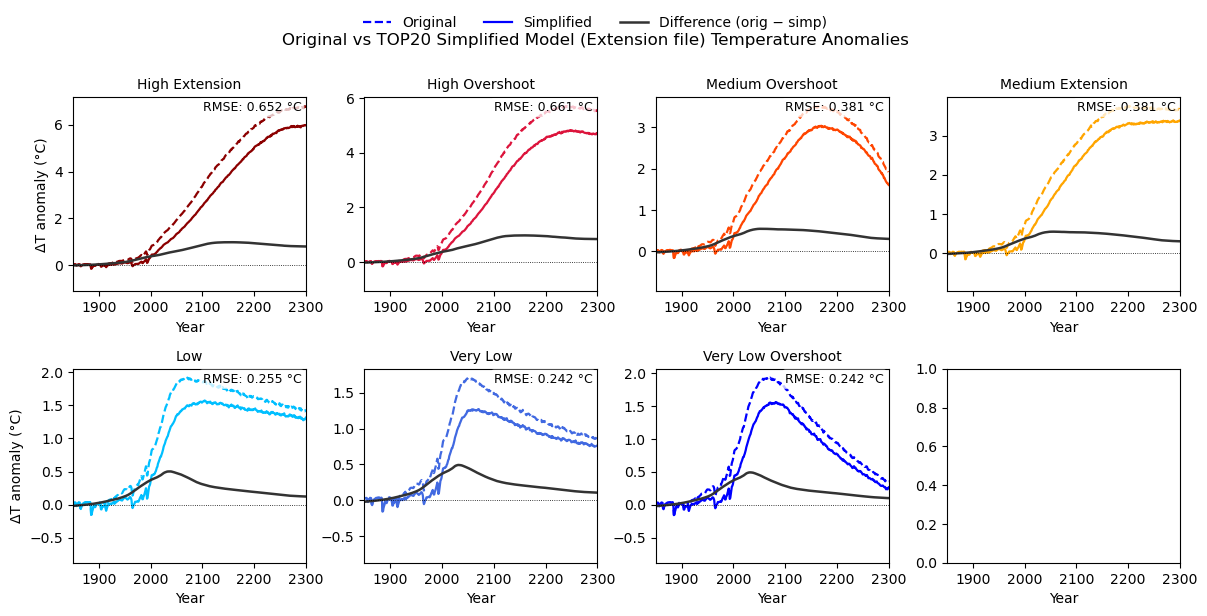

In [7]:
fig, ax = pl.subplots(2, 4, figsize=(12, 6), sharex=True)

# Choose styles for the three lines
STYLE_ORIG = dict(ls='--',  lw=1.6)
STYLE_SIMP = dict(ls='-', lw=1.6)
STYLE_DIFF = dict(ls='-',  lw=1.8)

for i, scenario in enumerate(f1.scenarios):
    a = ax[i // 4, i % 4]

    # --- Temperature anomalies (align baselines) ---
    temp1 = f1.temperature.loc[dict(scenario=scenario, layer=0)] - np.average(
        f1.temperature.loc[dict(scenario=scenario, timebounds=np.arange(1850, 1902), layer=0)],
        weights=weights_51yr, axis=0
    )
    temp2 = f3.temperature.loc[dict(scenario=scenario, layer=0)] - np.average(
        f3.temperature.loc[dict(scenario=scenario, timebounds=np.arange(1850, 1902), layer=0)],
        weights=weights_51yr, axis=0
    )

    # Signed difference
    delta = temp1 - temp2  # (time, ensemble?) → we’ll plot the median over members below if 2D

    # If arrays are (time, member), take the median trajectory for plotting
    def midline(x):
        x = np.asarray(x)
        return np.median(x, axis=1) if x.ndim == 2 else np.asarray(x)

    t = np.asarray(f1.timebounds)
    y1 = midline(temp1)
    y2 = midline(temp2)
    yd = midline(delta)

    # Colors per scenario for the two model lines; diff in neutral color
    scen_color = colors.get(f1.scenarios[i], 'C0')

    p1, = a.plot(t, y1, color=scen_color, **STYLE_ORIG, label='Original')
    p2, = a.plot(t, y2, color=scen_color, **STYLE_SIMP, label='Simplified')
    p3, = a.plot(t, yd, color='0.2',      **STYLE_DIFF, label='Difference (orig − simp)')

    a.axhline(0, color="k", ls=":", lw=0.6)
    a.set_xlim(1850, 2300)
    a.set_title(fancy_titles.get(f1.scenarios[i], f1.scenarios[i]), fontsize=10)
    if i % 4 == 0:
        a.set_ylabel("ΔT anomaly (°C)")

    # --- RMSE (over all times & ensemble members) ---
    rmse = np.sqrt(np.nanmean(np.asarray(delta)**2))
    a.text(
        0.98, 0.98, f"RMSE: {rmse:.3f} °C",
        transform=a.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.75)
    )

# Shared legend (once) — uses the artists from the last loop
fig.legend(
    handles=[p1, p2, p3], loc='upper center', ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.03)
)

for a in ax[0, :]:
    a.tick_params(axis='x', which='both', labelbottom=True)
    a.set_xlabel("Year")

for a in ax[1, :]:
    a.tick_params(axis='x', which='both', labelbottom=True)
    a.set_xlabel("Year")

pl.suptitle("Original vs TOP20 Simplified Model (Extension file) Temperature Anomalies")
fig.tight_layout(rect=[0, 0, 1, 0.98])


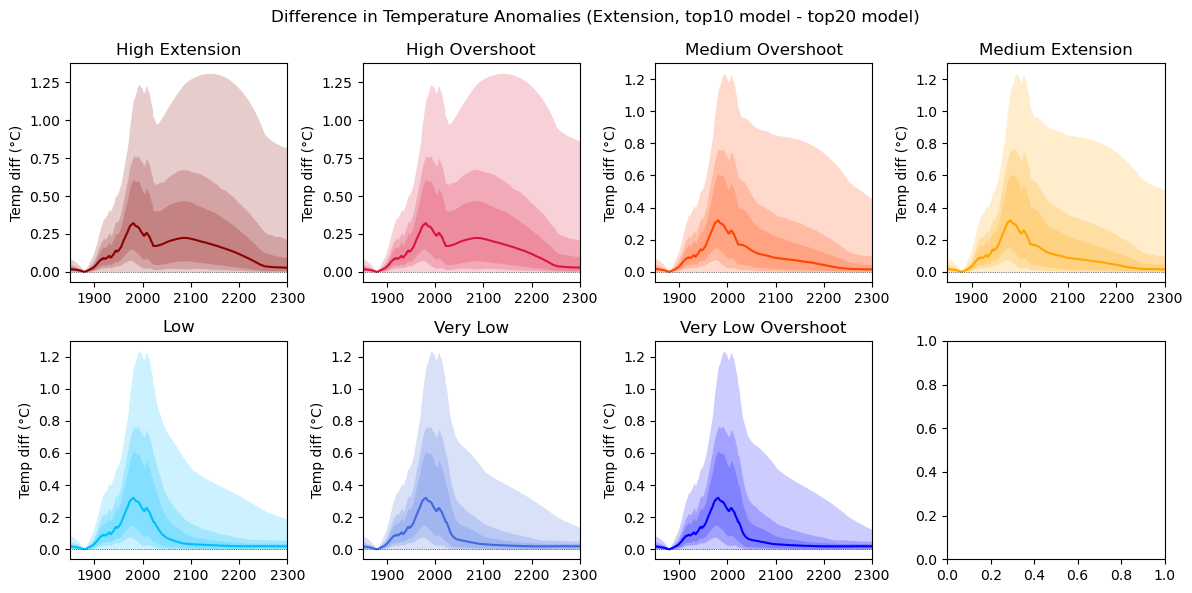

In [8]:
fig, ax = pl.subplots(2, 4, figsize=(12, 6))

for i, scenario in enumerate(f1.scenarios):
    # Calculate the temperature anomaly for f1
    temp1 = f2.temperature.loc[dict(scenario=scenario, layer=0)] - np.average(
        f2.temperature.loc[dict(scenario=scenario, timebounds=np.arange(1850, 1902), layer=0)],
        weights=weights_51yr,
        axis=0
    )
    # Same for f3
    temp2 = f3.temperature.loc[dict(scenario=scenario, layer=0)] - np.average(
        f3.temperature.loc[dict(scenario=scenario, timebounds=np.arange(1850, 1902), layer=0)],
        weights=weights_51yr,
        axis=0
    )

    # Difference between the two models
    diff = abs(temp1 - temp2)

    # Shaded percentile ranges for the difference
    for pp in ((0, 100), (5, 95), (16, 84)):
        ax[i // 4, i % 4].fill_between(
            f1.timebounds,
            np.percentile(diff, pp[0], axis=1),
            np.percentile(diff, pp[1], axis=1),
            color=colors[f1.scenarios[i]],
            alpha=0.2,
            lw=0
        )

    # Median difference line
    ax[i // 4, i % 4].plot(
        f1.timebounds,
        np.median(diff, axis=1),
        color=colors[f1.scenarios[i]],
    )

    ax[i // 4, i % 4].set_xlim(1850, 2300)
    ax[i // 4, i % 4].axhline(0, color="k", ls=":", lw=0.5)
    ax[i // 4, i % 4].set_title(fancy_titles[f1.scenarios[i]])
    ax[i // 4, i % 4].set_ylabel("Temp diff (°C)")

pl.suptitle("Difference in Temperature Anomalies (Extension, top10 model - top20 model)")
fig.tight_layout()
